<a href="https://colab.research.google.com/github/ninoz-42/Evaluating-Machine-Learning-Models-for-Predicting-Commuting-Route-Disruptions-in-London/blob/main/xG_Model_SHAP_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install statsbombpy shap xgboost -q

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsbombpy import sb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [16]:
competitions_to_use = [
    (43, 3),    # FIFA World Cup 2018
    (11, 42),   # La Liga 2019/20
    (11, 90),   # La Liga 2020/21
    (16, 4),    # Champions League 2019/20
    (72, 30),   # Women's World Cup 2019
]

all_shots = []

for comp_id, season_id in competitions_to_use:
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        print(f"Found {len(matches)} matches (comp {comp_id}, season {season_id})")
        for _, match in matches.iterrows():
            try:
                events = sb.events(match_id=match['match_id'])
                shots = events[events['type'] == 'Shot'].copy()
                if len(shots) > 0:
                    all_shots.append(shots)
            except:
                continue
    except Exception as e:
        print(f"  Skipping comp {comp_id}, season {season_id}: {e}")

shots_df = pd.concat(all_shots, ignore_index=True)
print(f"\nTotal shots collected: {len(shots_df)}")

Found 64 matches (comp 43, season 3)
Found 33 matches (comp 11, season 42)
Found 35 matches (comp 11, season 90)
Found 1 matches (comp 16, season 4)
Found 52 matches (comp 72, season 30)

Total shots collected: 4641


In [17]:
def extract_features(df):
    features = pd.DataFrame()
    features['x'] = df['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
    features['y'] = df['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
    features['distance_to_goal'] = np.sqrt((120 - features['x'])**2 + (40 - features['y'])**2)
    features['angle_to_goal'] = np.degrees(np.arctan2(
        7.32 * (120 - features['x']),
        (120 - features['x'])**2 + (features['y'] - 40)**2 - (7.32/2)**2
    )).clip(lower=0)
    features['body_part'] = df['shot_body_part'].apply(
        lambda x: x.get('name', 'Unknown') if isinstance(x, dict) else 'Unknown')
    features['technique'] = df['shot_technique'].apply(
        lambda x: x.get('name', 'Unknown') if isinstance(x, dict) else 'Unknown')
    features['shot_type'] = df['shot_type'].apply(
        lambda x: x.get('name', 'Unknown') if isinstance(x, dict) else 'Unknown')
    features['play_pattern'] = df['play_pattern'].apply(
        lambda x: x.get('name', 'Unknown') if isinstance(x, dict) else 'Unknown')
    features['under_pressure'] = df['under_pressure'].fillna(False).astype(int)
    features['first_time'] = df['shot_first_time'].fillna(False).astype(int)
    def count_defenders(freeze):
        if not isinstance(freeze, list):
            return np.nan
        return sum(1 for p in freeze if not p.get('teammate', True))
    features['n_defenders'] = df['shot_freeze_frame'].apply(count_defenders)
    features['is_goal'] = (df['shot_outcome'] == 'Goal').astype(int)
    return features

features_df = extract_features(shots_df)
features_df = features_df[features_df['shot_type'] != 'Penalty']

print(f"Features extracted for {len(features_df)} shots (penalties excluded)")
print(f"Goals: {features_df['is_goal'].sum()} ({features_df['is_goal'].mean()*100:.1f}%)")

Features extracted for 4641 shots (penalties excluded)
Goals: 540 (11.6%)


In [21]:
# Fill missing values
features_df['n_defenders'] = features_df['n_defenders'].fillna(features_df['n_defenders'].median())
features_df = features_df.dropna(subset=['x', 'y', 'distance_to_goal', 'angle_to_goal'])

# Encode categorical variables
label_encoders = {}
categorical_cols = ['body_part', 'technique', 'shot_type', 'play_pattern']
for col in categorical_cols:
    le = LabelEncoder()
    features_df[col + '_encoded'] = le.fit_transform(features_df[col].astype(str))
    label_encoders[col] = le

# Feature matrix
feature_columns = [
    'x', 'y', 'distance_to_goal', 'angle_to_goal',
    'under_pressure', 'first_time', 'n_defenders',
    'body_part_encoded', 'technique_encoded', 'shot_type_encoded', 'play_pattern_encoded'
]
feature_names = [
    'Shot X Position', 'Shot Y Position', 'Distance to Goal', 'Angle to Goal',
    'Under Pressure', 'First Time Shot', 'Defenders in Frame',
    'Body Part', 'Technique', 'Shot Type', 'Play Pattern'
]

X = features_df[feature_columns].values
y = features_df['is_goal'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {len(X_train)} shots ({y_train.sum()} goals)")
print(f"Test: {len(X_test)} shots ({y_test.sum()} goals)")

Training: 3712 shots (432 goals)
Test: 929 shots (108 goals)


In [22]:
# Model 1: Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression trained")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest trained")

# Model 3: XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                     min_child_weight=10, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
print("XGBoost trained")

Logistic Regression trained
Random Forest trained
XGBoost trained


In [24]:
def evaluate(model, name):
    proba = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, proba)
    ll = log_loss(y_test, proba)
    brier = brier_score_loss(y_test, proba)
    cv = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(f"\n{name}:")
    print(f"  ROC-AUC:     {roc:.4f}")
    print(f"  Log Loss:    {ll:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"  CV ROC-AUC:  {cv.mean():.4f} (±{cv.std():.4f})")
    return {'Model': name, 'ROC-AUC': round(roc,4), 'Log Loss': round(ll,4),
            'Brier Score': round(brier,4)}

r1 = evaluate(lr, "Logistic Regression")
r2 = evaluate(rf, "Random Forest")
r3 = evaluate(xgb, "XGBoost")

results_df = pd.DataFrame([r1, r2, r3])
print("\n\nComparison Table:")
print(results_df.to_string(index=False))


Logistic Regression:
  ROC-AUC:     0.7963
  Log Loss:    0.3001
  Brier Score: 0.0888
  CV ROC-AUC:  0.7749 (±0.0205)

Random Forest:
  ROC-AUC:     0.7965
  Log Loss:    0.2839
  Brier Score: 0.0806
  CV ROC-AUC:  0.7762 (±0.0249)

XGBoost:
  ROC-AUC:     0.7878
  Log Loss:    0.2927
  Brier Score: 0.0830
  CV ROC-AUC:  0.7636 (±0.0157)


Comparison Table:
              Model  ROC-AUC  Log Loss  Brier Score
Logistic Regression   0.7963    0.3001       0.0888
      Random Forest   0.7965    0.2839       0.0806
            XGBoost   0.7878    0.2927       0.0830


<Figure size 1000x600 with 0 Axes>

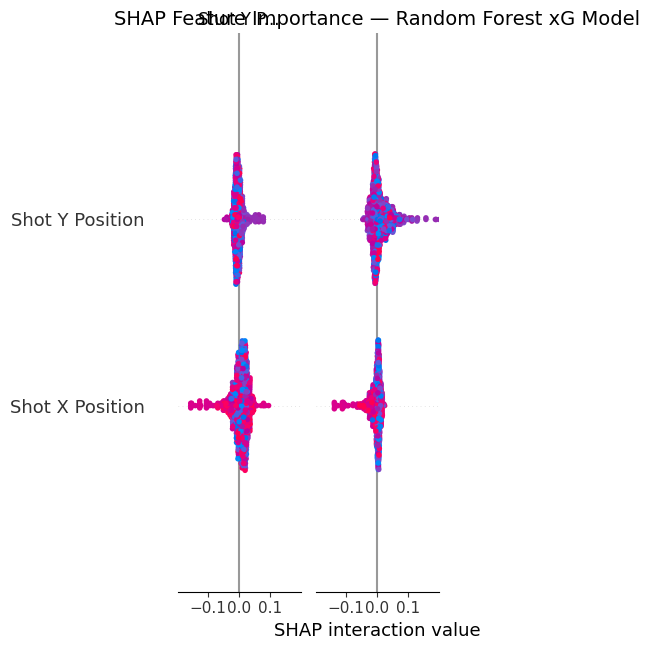

<Figure size 1000x600 with 0 Axes>

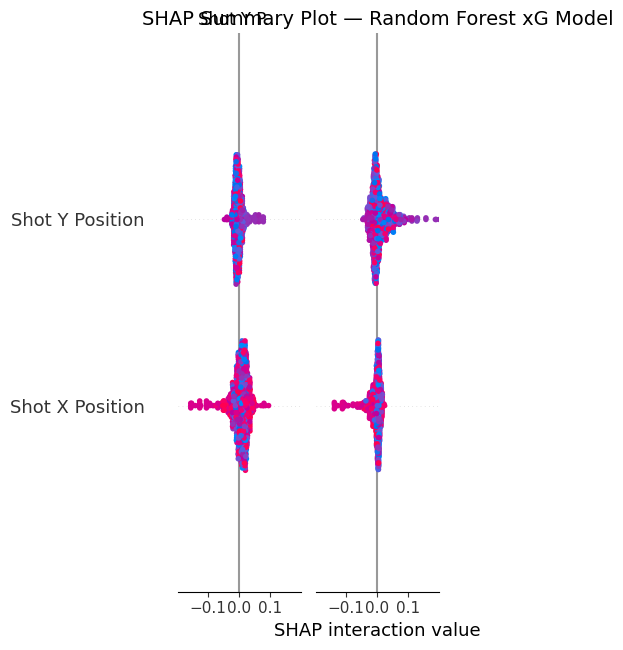

Saved: shap_feature_importance.png, shap_beeswarm.png


In [25]:
# SHAP Analysis on Random Forest (best model)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For Random Forest, shap_values is [class_0, class_1] — we want class 1 (goal)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Plot 1: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Random Forest xG Model", fontsize=14)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Beeswarm Plot (shows direction of effect)
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot — Random Forest xG Model", fontsize=14)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved: shap_feature_importance.png, shap_beeswarm.png")

SHAP values shape: (929, 11, 2)
X_test shape: (929, 11)
Fixed: reduced interaction values to regular SHAP values


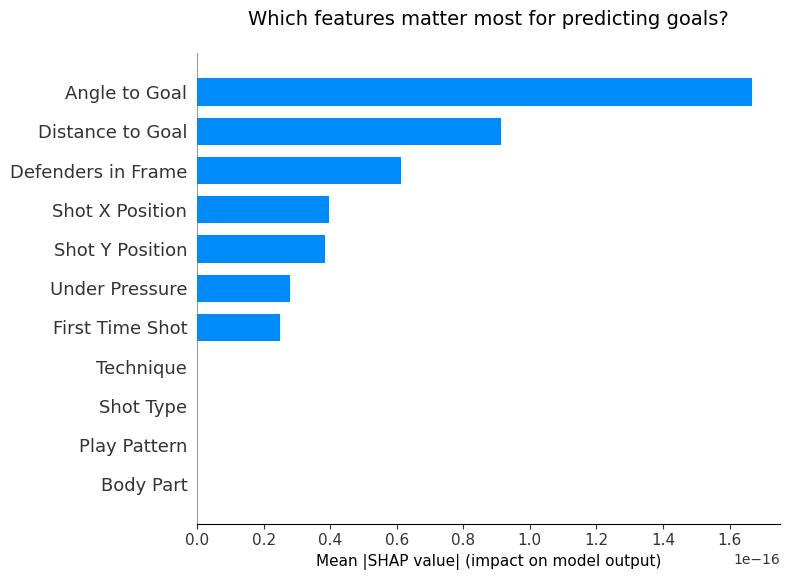

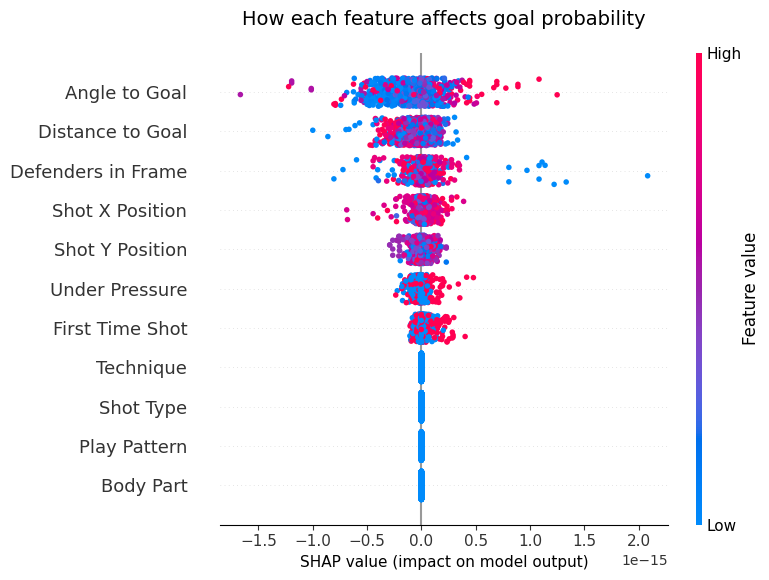

In [26]:
# Check SHAP values shape
print(f"SHAP values shape: {np.array(sv).shape}")
print(f"X_test shape: {X_test.shape}")

# If sv has 3 dimensions, it computed interaction values — we need to sum
if np.array(sv).ndim == 3:
    sv = np.array(sv).sum(axis=2)
    print("Fixed: reduced interaction values to regular SHAP values")

# Plot 1: Feature Importance Bar Chart
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Which features matter most for predicting goals?", fontsize=14, pad=20)
plt.xlabel("Mean |SHAP value| (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Beeswarm Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False)
plt.title("How each feature affects goal probability", fontsize=14, pad=20)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

Shape: (929, 11)


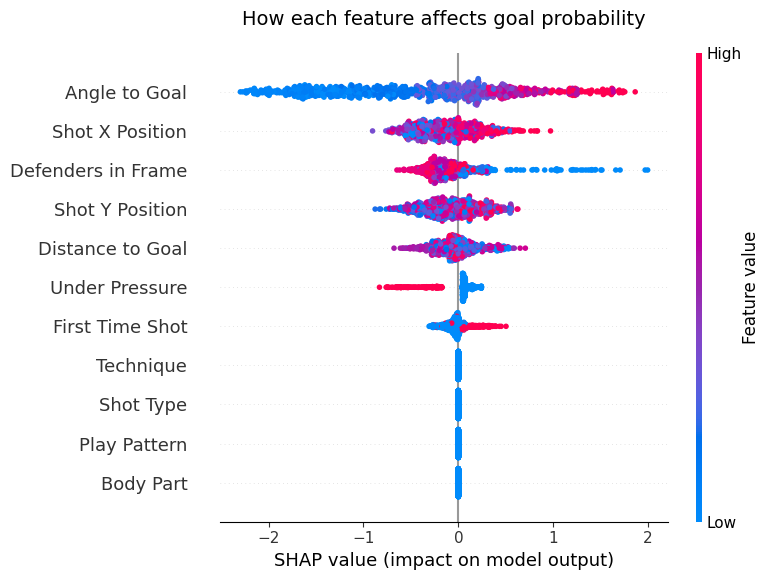

In [29]:
# Use XGBoost for SHAP (cleaner output)
explainer3 = shap.TreeExplainer(xgb)
sv3 = explainer3.shap_values(X_test)

print(f"Shape: {sv3.shape}")  # should be (929, 11) — 2D, not 3D

# Beeswarm Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(sv3, X_test, feature_names=feature_names, show=False)
plt.title("How each feature affects goal probability", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

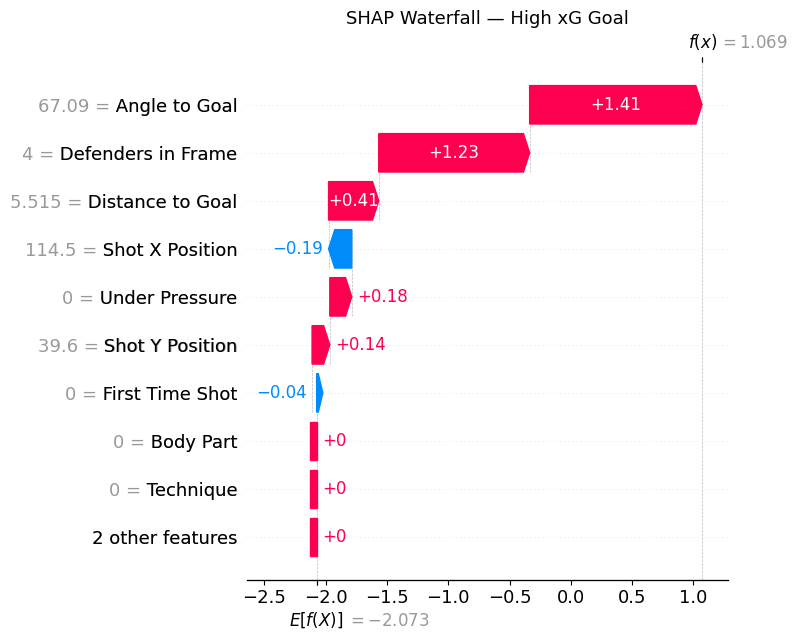

Saved: shap_waterfall_high_xg_goal.png


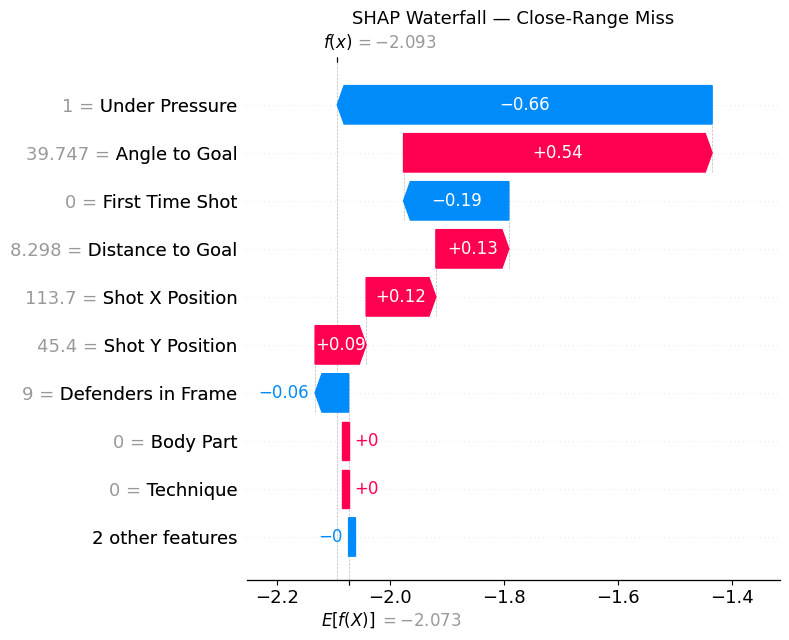

Saved: shap_waterfall_closerange_miss.png


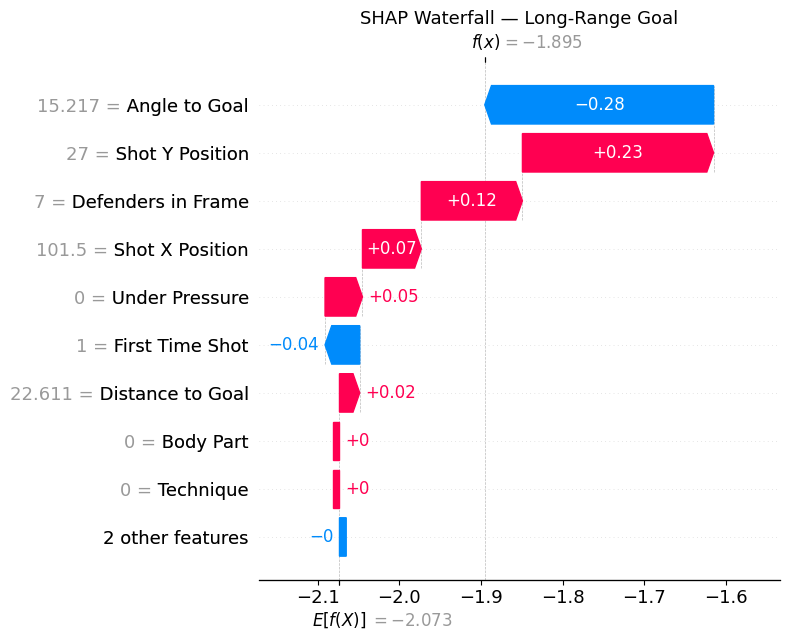

Saved: shap_waterfall_longrange_goal.png


In [30]:
# 3 Waterfall plots: a goal, a close miss, and a long-range goal
base_val = explainer3.expected_value

goals_idx = np.where(y_test == 1)[0]
misses_idx = np.where(y_test == 0)[0]

# Example 1: High xG goal
goal_probs = xgb.predict_proba(X_test[goals_idx])[:, 1]
ex1 = goals_idx[np.argmax(goal_probs)]

# Example 2: Close-range miss
close = misses_idx[X_test[misses_idx, 2] < 10]
ex2 = close[0] if len(close) > 0 else misses_idx[0]

# Example 3: Long-range goal
far = goals_idx[X_test[goals_idx, 2] > 20]
ex3 = far[0] if len(far) > 0 else goals_idx[-1]

examples = [(ex1, "High xG Goal"), (ex2, "Close-Range Miss"), (ex3, "Long-Range Goal")]

for idx, title in examples:
    exp = shap.Explanation(values=sv3[idx], base_values=base_val,
                           data=X_test[idx], feature_names=feature_names)
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(exp, show=False)
    plt.title(f"SHAP Waterfall — {title}", fontsize=13)
    plt.tight_layout()
    fname = f"shap_waterfall_{title.lower().replace(' ','_').replace('-','')}.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")